In [1]:
# Move to project directory
import os
os.chdir("/home/mdarif/MLOPS/wine-quality-prediction-system")
print(os.getcwd())

/home/mdarif/MLOPS/wine-quality-prediction-system


# Table of Content

**1. Introduction**

**2. Experiment Setup**
- 2.1 Importing Libraries
- 2.2 Project Configuration
- 2.3 MLflow and DagsHub Setup
- 2.4 Loading Dataset

**3. Data Preparation**
- 3.1 Duplicate Check
- 3.2 Removing Duplicates
- 3.3 Descriptive Statistics
- 3.4 Train-Test Split

**4. Baseline Model**
- 4.1 Baseline Model
- 4.2 Baseline Evaluation

**5. Model Experimentation**
- 5.1 Model Definitions
- 5.2 Hyperparameter Search Strategy
- 5.3 Model Training
- 5.4 Model Comparison
- 5.5 Model Ranking
- 5.6 Model Selection

**6. Hyperparameter Optimization**
- 6.1 RandomizedSearchCV
- 6.2 Optuna with (TPE Bayesian Optimization)
- 6.3 Train Models from Each Optimization Method
- 6.4 Generate Test Predictions
- 6.5 Optimization Method Comparison
- 6.6 Select Optimization Method
- 6.7 Set the Final Parameters

**7. Final Model Evaluation**
- 7.1 Final Model
- 7.2 Regression Metrics
- 7.3 MLflow Helper Functions
- 7.4 Actual vs Predicted
- 7.5 Residual Distribution
- 7.6 Residual vs Predicted
- 7.7 Rounded-Predicted Accuracy
- 7.8 Feature Importance
- 7.9 Error Analysis by Quality Score

**8. MLflow Experiment Tracking**
- 8.1 Final Model Logging

**9. Conclusion**

## 1. Introduction

This notebook covers model experimentation for the red wine quality
dataset a baseline, 11 regressors compared, Bayesian tuning on the
winner, and a closer look at what the final model actually gets right and
wrong, not just its aggregate R2.

Quality is a 0-10 sensory score, but this dataset only has scores 3-8, and
it's heavily concentrated at 5 and 6 about 82% of samples, per the EDA
notebook. R2 is the primary metric for model selection, with RMSE and MAE
tracked for interpretability since they're in the same units as the
quality score itself.

## 2. Experiment Setup

### 2.1 Importing Libraries

In [2]:
# Import required libraries
import multiprocessing
import dagshub
import mlflow
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import tempfile
from dotenv import load_dotenv
from math import prod
from tqdm import tqdm
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score
)
from sklearn.inspection import permutation_importance
from mlflow.models import infer_signature

In [3]:
# Load environment variables
load_dotenv()

True

### 2.2 Project Configuration

In [4]:
# Set training configuration
total_cores = multiprocessing.cpu_count()
ENV = os.getenv("ENV", "development")

if ENV == "production":
    N_JOBS = 2
    N_ITER = 30
    CV = 5
else:
    N_JOBS = max(1, total_cores // 3)
    N_ITER = 10
    CV = 3

print(f"Environment: {ENV}")
print(f"Total cores: {total_cores}")
print(f"n_jobs: {N_JOBS}")
print(f"n_iter: {N_ITER}")
print(f"CV: {CV}")

Environment: development
Total cores: 12
n_jobs: 4
n_iter: 10
CV: 3


### 2.3 MLflow and DagsHub Setup

In [5]:
# Connect MLflow with DagsHub
dagshub.init(
    repo_owner="TechArif",
    repo_name="wine-quality-prediction-system",
    mlflow=True
)

mlflow.set_experiment("Wine Quality Prediction")

Accessing as TechArif

Initialized MLflow to track repo "TechArif/wine-quality-prediction-system"

Repository TechArif/wine-quality-prediction-system initialized!

<Experiment: artifact_location='mlflow-artifacts:/4155039a266a4a76b671f9ea87216a33', creation_time=1790006594166, experiment_id='0', last_update_time=1790006594166, lifecycle_stage='active', name='Wine Quality Prediction', tags={'mlflow.experimentKind': 'custom_model_development'}>

### 2.4 Loading Dataset

In [6]:
# Download dataset from Kaggle
kaggle_username = os.getenv("KAGGLE_USERNAME")
kaggle_api_token = os.getenv("KAGGLE_API_TOKEN")

if not kaggle_username or not kaggle_api_token:
    raise ValueError("KAGGLE_USERNAME and KAGGLE_API_TOKEN must be set.")

api = KaggleApi()
api.authenticate()

dataset = "uciml/red-wine-quality-cortez-et-al-2009"
download_dir = "/tmp/wine_quality"
os.makedirs(download_dir, exist_ok=True)

api.dataset_download_files(
    dataset=dataset,
    path=download_dir,
    unzip=True
)

file_path = os.path.join(
    download_dir,
    "winequality-red.csv"
)

print(file_path)

Dataset URL: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009
/tmp/wine_quality/winequality-red.csv


In [7]:
# Load the dataset and diplay the first five rows
df = pd.read_csv(file_path)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3. Data Preparation

### 3.1 Duplicate Check 

In [8]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_rows = df[df.duplicated(keep=False)]

print(f"Duplicate rows: {duplicate_count}")
print(duplicate_rows)

Duplicate rows: 240
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
4               7.4             0.700         0.00             1.9      0.076   
9               7.5             0.500         0.36             6.1      0.071   
11              7.5             0.500         0.36             6.1      0.071   
22              7.9             0.430         0.21             1.6      0.106   
...             ...               ...          ...             ...        ...   
1567            7.2             0.695         0.13             2.0      0.076   
1579            6.2             0.560         0.09             1.7      0.053   
1581            6.2             0.560         0.09             1.7      0.053   
1592            6.3             0.510         0.13             2.3      0.076   
1596            6.3             0.510         0.13             2.3      0.076   

      f

In [9]:
# Check duplicate features for different target values
feature_columns = df.columns.drop("quality")

duplicate_features = df[
    df.duplicated(subset=feature_columns, keep=False)
].sort_values(by=list(feature_columns))

target_counts = (
    duplicate_features.groupby(list(feature_columns))["quality"].nunique()
)

conflicting_duplicates = target_counts[target_counts > 1]
print(f"Conflicting duplicate groups: {len(conflicting_duplicates)}")

Conflicting duplicate groups: 0


### Observation

The dataset contains 240 exact duplicate rows. No conflicting duplicate groups were found, so identical feature values do not have different `quality` targets.

### 3.2 Removing Duplicates

In [10]:
# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (1359, 12)


### 3.3 Descriptive Statistics

In [11]:
# View summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


### 3.4 Train-Test Split

In [12]:
# Set target column
TARGET = "quality"

# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1359, 11)
Target shape: (1359,)


In [13]:
# Split the data into training and tests sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (1087, 11)
X_test: (272, 11)
y_train: (1087,)
y_test: (272,)


## 4. Baseline Model

### 4.1 Baseline Model

Before comparing the 11 regressors, a simple baseline model is established using DummyRegressor with the mean strategy. It predicts the mean training-set quality for every sample and provides a reference point for evaluating the regression models.

In [14]:
# Create the baseline model
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train)

DummyRegressor()

### 4.2 Baseline Evaluation

In [15]:
# Generate baseline predictions
baseline_pred = baseline_model.predict(X_test)

baseline_r2 = r2_score(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Baseline R2: {baseline_r2:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline MAE: {baseline_mae:.4f}")

Baseline R2: -0.0063
Baseline RMSE: 0.8443
Baseline MAE: 0.7049


### Observation

The mean baseline achieves an R2 of -0.0063, with RMSE of 0.8443 and MAE of 0.7049. These values provide the reference point for comparing the regression models in the next section.

## 5. Model Experimentation

### 5.1 Model Definitions

Eleven regressors models are compared: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`, `DecisionTree`, `RandomForest`, `SVR`, `KNN`, `GradientBoosting`, `XGBoost` and `LightGBM`. Scaling is applied within pipelines for linear and distace-based models while tree-based models are used without feature scaling.

In [16]:
# Define models and hyperparameter search spaces
models = {
    "LinearRegression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "params": {}
    },

    "Ridge": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ]),
        "params": {
            "model__alpha": [0.001, 0.01, 0.1, 1, 10, 50]
        }
    },

    "Lasso": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(max_iter=5000))
        ]),
        "params": {
            "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]
        }
    },

    "ElasticNet": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(max_iter=5000, random_state=42))
        ]),
        "params": {
            "model__alpha": [0.001, 0.01, 0.1, 1],
            "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    },

    "DecisionTree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": list(range(3, 16)),
            "min_samples_split": list(range(2, 21)),
            "min_samples_leaf": list(range(1, 9)),
            "criterion": ["squared_error", "friedman_mse"]
        }
    },

    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": list(range(100, 301, 50)),
            "max_depth": list(range(5, 16)),
            "min_samples_split": list(range(2, 21)),
            "min_samples_leaf": list(range(1, 9)),
            "max_features": ["sqrt", "log2"]
        }
    },

    "SVR": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR())
        ]),
        "params": {
            "model__C": [0.1, 1, 10, 50, 100],
            "model__kernel": ["rbf", "linear", "poly"],
            "model__gamma": ["scale", "auto"],
            "model__epsilon": [0.01, 0.05, 0.1, 0.2]
        }
    },

    "KNN": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor())
        ]),
        "params": {
            "model__n_neighbors": list(range(3, 21)),
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan", "minkowski"]
        }
    },

    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": list(range(50, 201, 50)),
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": list(range(2, 6)),
            "min_samples_split": list(range(2, 21)),
            "min_samples_leaf": list(range(1, 9)),
            "subsample": [0.7, 0.8, 0.9]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=1
        ),
        "params": {
            "n_estimators": list(range(50, 201, 50)),
            "max_depth": list(range(2, 8)),
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "subsample": [0.6, 0.7, 0.8, 0.9],
            "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
            "min_child_weight": list(range(1, 11)),
            "reg_alpha": [0, 0.01, 0.1, 1],
            "reg_lambda": list(range(1, 11))
        }
    },

    "LightGBM": {
        "model": LGBMRegressor(
            random_state=42,
            n_jobs=1,
            verbose=-1
        ),
        "params": {
            "n_estimators": list(range(50, 201, 50)),
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "max_depth": [-1, 3, 5, 7],
            "num_leaves": [15, 31, 50],
            "subsample": [0.7, 0.8, 0.9],
            "colsample_bytree": [0.7, 0.8, 0.9]
        }
    }
}

### 5.2 Hyperparameter Search Strategy

In [17]:
# Set the maximum search space size for GridSearchCV
SEARCH_SPACE_LIMIT = 200

In [18]:
# Calculate the number of hyperparmeter combinations
for name, config in models.items():
    total_combinations = prod(len(values) for values in config["params"].values())
    print(f"{name}: {total_combinations} combinations")

LinearRegression: 1 combinations
Ridge: 6 combinations
Lasso: 5 combinations
ElasticNet: 20 combinations
DecisionTree: 3952 combinations
RandomForest: 16720 combinations
SVR: 120 combinations
KNN: 108 combinations
GradientBoosting: 21888 combinations
XGBoost: 614400 combinations
LightGBM: 1728 combinations


### 5.3 Model Training

In [19]:
# Store model evaluation results and fitted models
results = []
trained_models = {}

In [20]:
# Train and evaluate all models
for name, config in tqdm(models.items(), desc="Training Models", leave=True, ncols=100):

    model = config["model"]
    params = config["params"]

    # Run hyperparameter search
    if params:
        total_combinations = prod(len(values) for values in params.values())

        # Select hyperparameter search strategy
        if total_combinations <= SEARCH_SPACE_LIMIT:
            search = GridSearchCV(
                model,
                params,
                cv=CV,
                scoring="r2",
                n_jobs=N_JOBS,
                refit=True,
                verbose=0
            )
            search_type = "GridSearchCV"
        else:
            search = RandomizedSearchCV(
                model,
                params,
                n_iter=N_ITER,
                cv=CV,
                scoring="r2",
                n_jobs=N_JOBS,
                random_state=42,
                refit=True,
                verbose=0
            )
            search_type = "RandomizedSearchCV"

    else:
        search = model
        search_type = "No Hyperparameter Search"

    # Train and tune the model
    search.fit(X_train, y_train)

    best_model_current = search.best_estimator_ if params else search
    best_params_current = search.best_params_ if params else {}
    cv_score = search.best_score_ if params else None

    # Store fitted model
    trained_models[name] = best_model_current

    # Training predictions
    y_train_pred = best_model_current.predict(X_train)

    # Train metrics
    train_r2 = r2_score(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)

    # Test predictions
    y_test_pred = best_model_current.predict(X_test)

    # Test metrics
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae =  mean_absolute_error(y_test, y_test_pred)

    # Overfitting check
    r2_gap = np.abs(train_r2 - test_r2)

    # Log experiments to MLflow
    with mlflow.start_run(run_name=name):

        # Log hyperparameter search details to MLflow
        mlflow.log_param("model", name)
        mlflow.log_param("search_method", search_type)
        mlflow.log_params(best_params_current)

        # Log model performance metrics to MLflow
        if cv_score is not None:
            mlflow.log_metric("CV_R2", cv_score)
        mlflow.log_metric("Train_R2", train_r2)
        mlflow.log_metric("Test_R2", test_r2)
        mlflow.log_metric("R2_Gap", r2_gap)
        mlflow.log_metric("Train_RMSE", train_rmse)
        mlflow.log_metric("Test_RMSE", test_rmse)
        mlflow.log_metric("Train_MAE", train_mae)
        mlflow.log_metric("Test_MAE", test_mae)

        # Store results for model comparison
        results.append({
            "Model": name,
            "Search_Method": search_type,
            "CV_R2": round(cv_score, 4) if cv_score is not None else None,
            "Best_Params": best_params_current,
            "Train_R2": round(train_r2, 4),
            "Test_R2": round(test_r2, 4),
            "R2_Gap": round(r2_gap, 4),
            "Train_RMSE": round(train_rmse, 4),
            "Test_RMSE": round(test_rmse, 4),
            "Train_MAE": round(train_mae, 4),
            "Test_MAE": round(test_mae, 4),
        })

        # Display results
        tqdm.write("\n" + "=" *60)
        tqdm.write(f"Model: {name}")
        tqdm.write(f"Search_Method: {search_type}")
        tqdm.write(f"CV_R2: {round(cv_score, 4) if cv_score is not None else None}")
        tqdm.write(f"Best_Params: {best_params_current}")
        tqdm.write(f"Train_R2: {round(train_r2, 4)}")
        tqdm.write(f"Test_R2: {round(test_r2, 4)}")
        tqdm.write(f"R2_Gap: {round(r2_gap, 4)}")
        tqdm.write(f"Train_RMSE: {round(train_rmse, 4)}")
        tqdm.write(f"Test_RMSE: {round(test_rmse, 4)}")
        tqdm.write(f"Train_MAE: {round(train_mae, 4)}")
        tqdm.write(f"Test_MAE: {round(test_mae, 4)}")
        tqdm.write("=" *60 + "\n")

Training Models:   0%|                                                       | 0/11 [00:00<?, ?it/s]

Training Models:   0%|                                                       | 0/11 [00:04<?, ?it/s]


Model: LinearRegression
Search_Method: No Hyperparameter Search
CV_R2: None
Best_Params: {}
Train_R2: 0.352
Test_R2: 0.3915
R2_Gap: 0.0395
Train_RMSE: 0.6585
Test_RMSE: 0.6565
Train_MAE: 0.5107
Test_MAE: 0.5041



2026/09/28 13:02:17 INFO mlflow.tracking._tracking_service.client: 🏃 View run LinearRegression at: https://dagshub.com/TechArif/wine-quality-prediction-system.mlflow/#/experiments/0/runs/1ce6f609743a461a83f1b8961641f607.
2026/09/28 13:02:17 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/TechArif/wine-quality-prediction-system.mlflow/#/experiments/0.
Training Models:   9%|████▎                                          | 1/11 [00:11<00:51,  5.13s/it]


Model: Ridge
Search_Method: GridSearchCV
CV_R2: 0.3404
Best_Params: {'model__alpha': 10}
Train_R2: 0.3519
Test_R2: 0.3936
R2_Gap: 0.0417
Train_RMSE: 0.6586
Test_RMSE: 0.6554
Train_MAE: 0.5107
Test_MAE: 0.5038



...

2026/09/28 13:06:11 INFO mlflow.tracking._tracking_service.client: 🏃 View run GradientBoosting at: https://dagshub.com/TechArif/wine-quality-prediction-system.mlflow/#/experiments/0/runs/4dfe1d50d4aa448bbf94263a013fce02.
2026/09/28 13:06:11 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/TechArif/wine-quality-prediction-system.mlflow/#/experiments/0.
Training Models:  82%|██████████████████████████████████████▍        | 9/11 [04:35<00:58, 29.36s/it]


Model: XGBoost
Search_Method: RandomizedSearchCV
CV_R2: 0.3554
Best_Params: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 150, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Train_R2: 0.5497
Test_R2: 0.4773
R2_Gap: 0.0724
Train_RMSE: 0.549
Test_RMSE: 0.6085
Train_MAE: 0.4292
Test_MAE: 0.4709



2026/09/28 13:06:48 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost at: https://dagshub.com/TechArif/wine-quality-prediction-system.mlflow/#/experiments/0/runs/24779877f8784099bd7a96857e2304de.
2026/09/28 13:06:48 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/TechArif/wine-quality-prediction-system.mlflow/#/experiments/0.
Training Models:  91%|█████████████████████████████████████████▊    | 10/11 [04:57<00:31, 31.44s/it]


Model: LightGBM
Search_Method: RandomizedSearchCV
CV_R2: 0.3467
Best_Params: {'subsample': 0.7, 'num_leaves': 15, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Train_R2: 0.5276
Test_R2: 0.4569
R2_Gap: 0.0707
Train_RMSE: 0.5623
Test_RMSE: 0.6202
Train_MAE: 0.4411
Test_MAE: 0.482



2026/09/28 13:07:10 INFO mlflow.tracking._tracking_service.client: 🏃 View run LightGBM at: https://dagshub.com/TechArif/wine-quality-prediction-system.mlflow/#/experiments/0/runs/3771df324b744847b62a687fbfb9c3df.
2026/09/28 13:07:10 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/TechArif/wine-quality-prediction-system.mlflow/#/experiments/0.
Training Models: 100%|██████████████████████████████████████████████| 11/11 [04:58<00:00, 27.15s/it]


### 5.4 Model Comparison

In [21]:
# Convert model results into a Dataframe
results_df = pd.DataFrame(results)
results_df

,Model,Search_Method,CV_R2,Best_Params,Train_R2,Test_R2,R2_Gap,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE
0,LinearRegression,No Hyperparameter Search,NaN,{},0.3520,0.3915,0.0395,0.6585,0.6565,0.5107,0.5041
1,Ridge,GridSearchCV,0.3404,{'model__alpha': 10},0.3519,0.3936,0.0417,0.6586,0.6554,0.5107,0.5038
2,Lasso,GridSearchCV,0.3404,{'model__alpha': 0.001},0.3519,0.3947,0.0428,0.6586,0.6548,0.5105,0.5033
3,ElasticNet,GridSearchCV,0.3409,"{'model__alpha': 0.01, 'model__l1_ratio': 0.5}",0.3507,0.3987,0.0480,0.6592,0.6526,0.5115,0.5018
4,DecisionTree,RandomizedSearchCV,0.2070,"{'min_samples_split': 5, 'min_samples_leaf': 3...",0.3902,0.3782,0.0120,0.6388,0.6637,0.5015,0.5274
5,RandomForest,RandomizedSearchCV,0.3535,"{'n_estimators': 300, 'min_samples_split': 16,...",0.5982,0.4560,0.1422,0.5186,0.6208,0.3992,0.4759
6,SVR,GridSearchCV,0.3361,"{'model__C': 0.1, 'model__epsilon': 0.2, 'mode...",0.3455,0.3993,0.0538,0.6618,0.6523,0.5071,0.4974
7,KNN,GridSearchCV,0.3100,"{'model__metric': 'manhattan', 'model__n_neigh...",1.0000,0.4183,0.5817,0.0000,0.6419,0.0000,0.4947
8,GradientBoosting,RandomizedSearchCV,0.3446,"{'subsample': 0.8, 'n_estimators': 200, 'min_s...",0.5281,0.4360,0.0921,0.5620,0.6321,0.4508,0.4930
9,XGBoost,RandomizedSearchCV,0.3554,"{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha...",0.5497,0.4773,0.0724,0.5490,0.6085,0.4292,0.4709


In [22]:
# Comapare the main evaluation metrics
comparison_df = results_df[[
    "Model",
    "Search_Method",
    "CV_R2",
    "Test_R2",
    "R2_Gap",
    "Test_RMSE",
    "Test_MAE"
]].copy()

comparison_df

,Model,Search_Method,CV_R2,Test_R2,R2_Gap,Test_RMSE,Test_MAE
0,LinearRegression,No Hyperparameter Search,NaN,0.3915,0.0395,0.6565,0.5041
1,Ridge,GridSearchCV,0.3404,0.3936,0.0417,0.6554,0.5038
2,Lasso,GridSearchCV,0.3404,0.3947,0.0428,0.6548,0.5033
3,ElasticNet,GridSearchCV,0.3409,0.3987,0.0480,0.6526,0.5018
4,DecisionTree,RandomizedSearchCV,0.2070,0.3782,0.0120,0.6637,0.5274
5,RandomForest,RandomizedSearchCV,0.3535,0.4560,0.1422,0.6208,0.4759
6,SVR,GridSearchCV,0.3361,0.3993,0.0538,0.6523,0.4974
7,KNN,GridSearchCV,0.3100,0.4183,0.5817,0.6419,0.4947
8,GradientBoosting,RandomizedSearchCV,0.3446,0.4360,0.0921,0.6321,0.4930
9,XGBoost,RandomizedSearchCV,0.3554,0.4773,0.0724,0.6085,0.4709


### 5.5 Model Ranking

In [23]:
# Rank models based on important evaluation metrics
ranking_df = comparison_df.copy()

ranking_df["CV_Rank"] = ranking_df["CV_R2"].rank(
    ascending=False, method="min"
)

ranking_df["R2_Rank"] = ranking_df["Test_R2"].rank(
    ascending=False, method="min"
)

ranking_df["RMSE_Rank"] = ranking_df["Test_RMSE"].rank(
    ascending=True, method="min"
)

ranking_df["MAE_Rank"] = ranking_df["Test_MAE"].rank(
    ascending=True, method="min"
)

# Keeps rank as nullable integers
ranking_df[[
    "CV_Rank", "R2_Rank", "RMSE_Rank", "MAE_Rank"
]] = ranking_df[[
    "CV_Rank", "R2_Rank", "RMSE_Rank", "MAE_Rank"
]].astype("Int64")

ranking_df

,Model,Search_Method,CV_R2,Test_R2,R2_Gap,Test_RMSE,Test_MAE,CV_Rank,R2_Rank,RMSE_Rank,MAE_Rank
0,LinearRegression,No Hyperparameter Search,NaN,0.3915,0.0395,0.6565,0.5041,<NA>,10,10,10
1,Ridge,GridSearchCV,0.3404,0.3936,0.0417,0.6554,0.5038,6,9,9,9
2,Lasso,GridSearchCV,0.3404,0.3947,0.0428,0.6548,0.5033,6,8,8,8
3,ElasticNet,GridSearchCV,0.3409,0.3987,0.0480,0.6526,0.5018,5,7,7,7
4,DecisionTree,RandomizedSearchCV,0.2070,0.3782,0.0120,0.6637,0.5274,10,11,11,11
5,RandomForest,RandomizedSearchCV,0.3535,0.4560,0.1422,0.6208,0.4759,2,3,3,2
6,SVR,GridSearchCV,0.3361,0.3993,0.0538,0.6523,0.4974,8,6,6,6
7,KNN,GridSearchCV,0.3100,0.4183,0.5817,0.6419,0.4947,9,5,5,5
8,GradientBoosting,RandomizedSearchCV,0.3446,0.4360,0.0921,0.6321,0.4930,4,4,4,4
9,XGBoost,RandomizedSearchCV,0.3554,0.4773,0.0724,0.6085,0.4709,1,1,1,1


### Observation

XGBoost showed the strongest overall performance with the highest Test R² (0.4773), lowest RMSE (0.6085) and lowest MAE (0.4709) followed by LightGBM and RandomForest. Linear and regularized models performed moderately while DecisionTree showed the weakest results.

### 5.5 Model Selection

In [24]:
# Identify the best model based on cross-validation R2
best_candidate = results_df.loc[results_df["CV_R2"].idxmax()]

best_model_name = best_candidate["Model"]
search_method = best_candidate["Search_Method"]
best_model = trained_models[best_model_name]
best_cv_r2 = best_candidate["CV_R2"]
best_params = best_candidate["Best_Params"]

print("=" * 70)
print("MODEL SELECTION")
print("-" * 70)
print(f"Model: {best_model_name}")
print(f"Search Method: {search_method}")
print(f"CV_R2: {best_cv_r2:.4f}")
print(f"Best Parameters: {best_params}")
print("=" * 70)

MODEL SELECTION
----------------------------------------------------------------------
Model: XGBoost
Search Method: RandomizedSearchCV
CV_R2: 0.3554
Best Parameters: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 150, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


In [25]:
# Display full parameter values and the selected model's row
pd.set_option("display.max_colwidth", None)

best_model_results = results_df[results_df["Model"] == best_model_name].iloc[0]
best_model_results.to_frame()

,9
Model,XGBoost
Search_Method,RandomizedSearchCV
CV_R2,0.3554
Best_Params,"{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 150, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}"
Train_R2,0.5497
Test_R2,0.4773
R2_Gap,0.0724
Train_RMSE,0.549
Test_RMSE,0.6085
Train_MAE,0.4292


In [26]:
# Display the best hyperparameter of the selected model
print("Best Parameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")

Best Parameters:
subsample: 0.8
reg_lambda: 5
reg_alpha: 1
n_estimators: 150
min_child_weight: 7
max_depth: 3
learning_rate: 0.05
colsample_bytree: 0.6


### Observation

XGBoost was selected based on the highest cross-validation R2 of 0.3554. Its selcted configuration is carried forward for further hyperparameter optimization in Secton 6.

## 6. Hyperparameter Optimization

The selected XGBoost model is further optimized using two approaches: RandomizedSearchCV and Optuna with the TPE sampler. The XGBoost search space contains 614,400 possible hyperparameter combinations, making exhaustive GridSearchCV impractical.

In [27]:
# Define the XGBoost hyperparameter grid
xgb_param_grid = {
    "n_estimators": list(range(50, 201, 50)),
    "max_depth": list(range(2, 8)),
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "min_child_weight": list(range(1, 11)),
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": list(range(1, 11))
}

grid_combinations = prod(len(values) for values in xgb_param_grid.values())

print(f"Xgboost grid size: {grid_combinations} combinations")
print(f"Total CV fits: {grid_combinations * CV}")

Xgboost grid size: 614400 combinations
Total CV fits: 1843200


### 6.1 RandomizedSearchCV

RandomizedSearchCV samples a fixed number of hyperparameter combinations from the search space instead of evaluating every possible combination. This makes it more practical for large search spaces.

In [28]:
# Run RandomizedSearchCV for XGBoost
random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=1),
    param_distributions=xgb_param_grid,
    n_iter=N_ITER,
    cv=CV,
    scoring="r2",
    random_state=42,
    n_jobs=N_JOBS,
    refit=True,
    verbose=1
)

random_search.fit(X_train, y_train)

xgb_random_best_params = random_search.best_params_
xgb_random_best_score = random_search.best_score_

print("RandomizedSearchCV Best CV_R2:", round(xgb_random_best_score, 4))
print("RandomizedSearchCV Best Parameters:")
print(xgb_random_best_params)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomizedSearchCV Best CV_R2: 0.3554
RandomizedSearchCV Best Parameters:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 150, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


### 6.2 Optuna (TPE Bayesian Optimization)

Optuna uses the Tree-structured Parzen Estimator (TPE) sampler to learn from previous trials and focus subsequent trials on promising regions of the search space.

In [29]:
# Tune XGBoost with Bayesian optimization
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "max_depth": trial.suggest_int("max_depth", 2, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_int("reg_lambda", 1, 10)
    }

    model = XGBRegressor(
        random_state=42,
        n_jobs=1,
        **params
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=CV,
        scoring="r2",
        n_jobs=N_JOBS
    )

    return scores.mean()

In [30]:
# Create and run Optuna study
OPTUNA_TRIALS =500

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=OPTUNA_TRIALS,
    show_progress_bar=True
)

xgb_optuna_best_params = study.best_params
xgb_optuna_best_score = study.best_value

print(f"Best Trial: {study.best_trial.number}")
print("Optuna Best CV Recall:", round(xgb_optuna_best_score, 4))
print("Optuna Best Parameters:")
print(xgb_optuna_best_params)

[I 2026-09-28 13:07:12,254] A new study created in memory with name: no-name-22db5d4e-0ca5-413b-ab06-098abeec6753


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-09-28 13:07:12,406] Trial 0 finished with value: 0.3199782371520996 and parameters: {'n_estimators': 106, 'max_depth': 7, 'learning_rate': 0.07587945476302646, 'subsample': 0.779597545259111, 'colsample_bytree': 0.6468055921327309, 'min_child_weight': 2, 'reg_alpha': 0.05808361216819946, 'reg_lambda': 9}. Best is trial 0 with value: 0.3199782371520996.
[I 2026-09-28 13:07:12,538] Trial 1 finished with value: 0.3231210907300313 and parameters: {'n_estimators': 140, 'max_depth': 6, 'learning_rate': 0.011852604486622221, 'subsample': 0.8909729556485984, 'colsample_bytree': 0.8497327922401265, 'min_child_weight': 3, 'reg_alpha': 0.18182496720710062, 'reg_lambda': 2}. Best is trial 1 with value: 0.3231210907300313.
[I 2026-09-28 13:07:12,597] Trial 2 finished with value: 0.33892850081125897 and parameters: {'n_estimators': 95, 'max_depth': 5, 'learning_rate': 0.048875051677790424, 'subsample': 0.6873687420594126, 'colsample_bytree': 0.7835558684167139, 'min_child_weight': 2, 'reg_al

### 6.3 Train Models and Each Optimization Method

In [31]:
# Train the best XGBoost models from exach optimization method
xgb_random_model = random_search.best_estimator_

xgb_optuna_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1,
    **study.best_params
)

xgb_optuna_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6241734252827049, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.04987043443262728, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=4, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=158, n_jobs=1,
             num_parallel_tree=None, random_state=42, ...)

### 6.4 Generate Test Predictions

In [32]:
# Generate test predictions for each optimization method
# RandomizedSearchCV
xgb_random_pred = xgb_random_model.predict(X_test)

# Optuna
xgb_optuna_pred = xgb_optuna_model.predict(X_test)

### 6.5 Optimization Method Comparison

In [33]:
# Compare test set performance across optimization methods
xgb_optimization_comparison = pd.DataFrame([
    {
        "Optimization_Method": "RandomizedSearchCV",
        "Test_R2": r2_score(y_test, xgb_random_pred),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, xgb_random_pred)),
        "Test_MAE": mean_absolute_error(y_test, xgb_random_pred)
    },
    {
        "Optimization_Method": "Optuna",
        "Test_R2": r2_score(y_test, xgb_optuna_pred),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, xgb_optuna_pred)),
        "Test_MAE": mean_absolute_error(y_test, xgb_optuna_pred)
    }
])

xgb_optimization_comparison.round(4)

,Optimization_Method,Test_R2,Test_RMSE,Test_MAE
0,RandomizedSearchCV,0.4773,0.6085,0.4709
1,Optuna,0.4568,0.6203,0.4761


### 6.6 Select Optimization Comparison

In [34]:
# Compare the optimization methods using the actual regression metric values
# so rounding does not affect the comparison.
randomized_cv_r2 = xgb_random_best_score
optuna_cv_r2 = study.best_value

print("=" * 70)
print(f"XGBOOST OPTIMIZATION COMPARISON")
print("-" * 70)
print(f"RandomizedSearch CV R2: {randomized_cv_r2:.4f}")
print(f"Optuna CV R2: {optuna_cv_r2:.4f}")
print("-" * 70)

cv_r2_scores = {
    "RandomizedSearchCV": randomized_cv_r2,
    "Optuna": optuna_cv_r2
}

best_method = max(
    cv_r2_scores,
    key=cv_r2_scores.get
)

print(f"Selected optimization method based on cv r2: {best_method}")
print("=" * 70)

XGBOOST OPTIMIZATION COMPARISON
----------------------------------------------------------------------
RandomizedSearch CV R2: 0.3554
Optuna CV R2: 0.3696
----------------------------------------------------------------------
Selected optimization method based on cv r2: Optuna


### 6.7 Set Final Parameters

In [35]:
# Get the best parameters from the selected optimization method
if best_method == "Optuna":
    best_params = xgb_optuna_best_params

else:
    best_params = xgb_random_best_params

print("Selected Optimization Method:", best_method)
print("Selected Parameters:")
print(best_params)

Selected Optimization Method: Optuna
Selected Parameters:
{'n_estimators': 158, 'max_depth': 2, 'learning_rate': 0.04987043443262728, 'subsample': 0.6004888511007855, 'colsample_bytree': 0.6241734252827049, 'min_child_weight': 4, 'reg_alpha': 0.7391650510229414, 'reg_lambda': 9}


### Observation

Optuna beat RandomizedSearchCV on CV_R2 (0.3697 vs 3554) so Optuna's parameters are the ones carried forward as the final config.

## 7. Final Model Evaluation 

### 7.1 Final Model 

In [36]:
# Use the selected XGBoost model and its optimization results
best_model_name = "XGBoost"
search_method = best_method
best_cv_r2 = study.best_value
best_params = study.best_params

best_model = XGBRegressor(
    random_state = 42,
    n_jobs = N_JOBS,
    **best_params
)

best_model.fit(X_train, y_train)

print("=" * 70)
print("FINAL MODEL")
print("-" * 70)
print(f"Model: {best_model_name}")
print(f"Optimization Method: {best_method}")
print(f"CV R2: {best_cv_r2:.4f}")
print(f"Best Parameters: {best_params}")
print("=" * 70)

FINAL MODEL
----------------------------------------------------------------------
Model: XGBoost
Optimization Method: Optuna
CV R2: 0.3696
Best Parameters: {'n_estimators': 158, 'max_depth': 2, 'learning_rate': 0.04987043443262728, 'subsample': 0.6004888511007855, 'colsample_bytree': 0.6241734252827049, 'min_child_weight': 4, 'reg_alpha': 0.7391650510229414, 'reg_lambda': 9}


### 7.2 Regression Metrics

In [37]:
# Generate predictions from the final XGBoost model
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Calculate final model metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
r2_gap = train_r2 - test_r2
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("=" * 70)
print("FINAL MODEL RESULTS")
print("-" * 70)
print(f"Model: {best_model_name}")
print(f"Optimization Method: {best_method}")
print(f"CV R2: {best_cv_r2:.6f}")
print(f"Best Parameters: {best_params}")
print("-" * 70)
print(f"Train R2: {train_r2:.4f}")
print(f"Test R2: {test_r2:.4f}")
print(f"R2 Gap: {r2_gap:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print("=" * 70)

FINAL MODEL RESULTS
----------------------------------------------------------------------
Model: XGBoost
Optimization Method: Optuna
CV R2: 0.369615
Best Parameters: {'n_estimators': 158, 'max_depth': 2, 'learning_rate': 0.04987043443262728, 'subsample': 0.6004888511007855, 'colsample_bytree': 0.6241734252827049, 'min_child_weight': 4, 'reg_alpha': 0.7391650510229414, 'reg_lambda': 9}
----------------------------------------------------------------------
Train R2: 0.4674
Test R2: 0.4568
R2 Gap: 0.0106
Train RMSE: 0.5970
Test RMSE: 0.6203
Train MAE: 0.4616
Test MAE: 0.4761


### Observation

The final XGBoost model achieved a **Test R2 of 0.4568**, with **Test RMSE of 0.6203** and **Test MAE of 0.4761**. The **R2 gap of 0.0106** indicated that training and test performance are relatively close. 

### Final Model vs Baseline

The baseline models predicts the mean target value for every test samples. It achieved R2 of -0.0063, RMSE of 0.8443 and MAE of 0.7049.

The final XGBoost model is compared against these baseline metrics using the same test. A useful model should improve upon the baseline by achieving a higher R2 and lower RMSE and MAE.

### 7.3 MLflow Helper Functions

Small helper functions are used to avoid repeating artifact-logging code.

In [38]:
# Small helpers so we don't repeat this logging boilerplate every time
def log_matplotlib_figure(fig, artifact_name, artifact_path="evaluation_plots"):
    """Saves a matplotlib figure to a temp file and logs it to the active MLflow run."""
    if not artifact_name.endswith(".png"):
        artifact_name += ".png"

    with tempfile.TemporaryDirectory() as tmp_dir:
        local_path = os.path.join(tmp_dir, artifact_name)
        fig.savefig(local_path, bbox_inches="tight", dpi=150)
        mlflow.log_artifact(local_path, artifact_path=artifact_path)


def log_dataframe_artifact(df, artifact_name, artifact_path="evaluation_tables"):
    """Saves a DataFrame as CSV and logs it to the active MLflow run."""
    if not artifact_name.endswith(".csv"):
        artifact_name += ".csv"

    with tempfile.TemporaryDirectory() as tmp_dir:
        local_path = os.path.join(tmp_dir, artifact_name)
        df.to_csv(local_path, index=False)
        mlflow.log_artifact(local_path, artifact_path=artifact_path)

### 7.4 Actual vs Predicted

The actual quality scores are compared with the continuous predictions produced by the final XGBoost model.

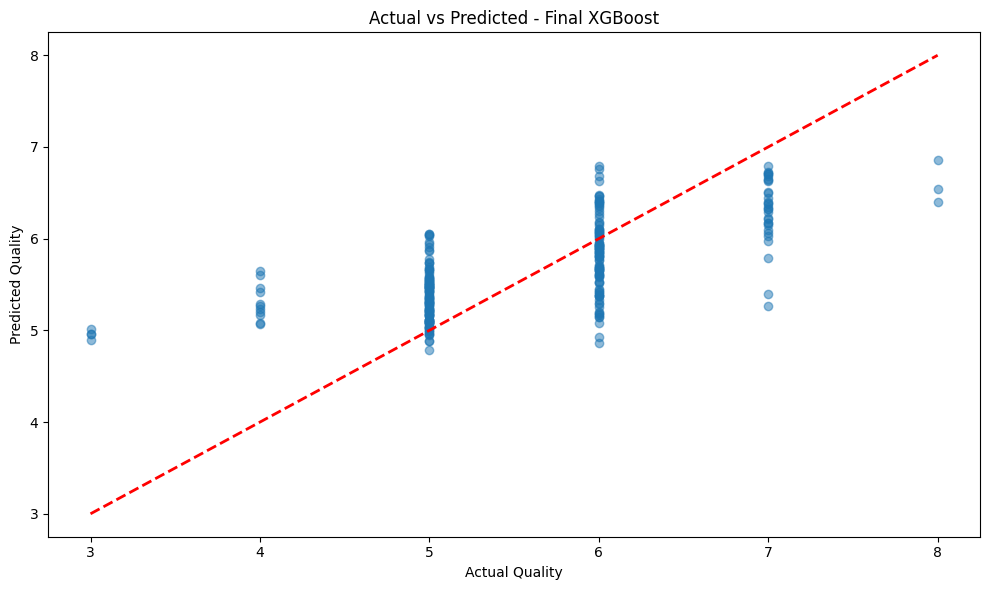

In [39]:
# Plot actual values against predicted values
fig_actual_predicted, ax = plt.subplots(figsize=(10, 6))

plt.scatter(y_test, y_test_pred, alpha=0.5)

# Add the ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2
)

plt.title("Actual vs Predicted - Final XGBoost")
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
fig_actual_predicted.tight_layout()
plt.show()

### Observation 

Since actual quality scores are discrete integers (3-8) but the model
predicts continuous values, expect vertical bands rather than a clean
diagonal scatter — that's normal for regression on an ordinal target.

### 7.5 Residual Distribution

Residuals are calculated as the difference between the actual and predicted quality scores. Their distribution helps examine the overall pattern the spread of prediction errors.

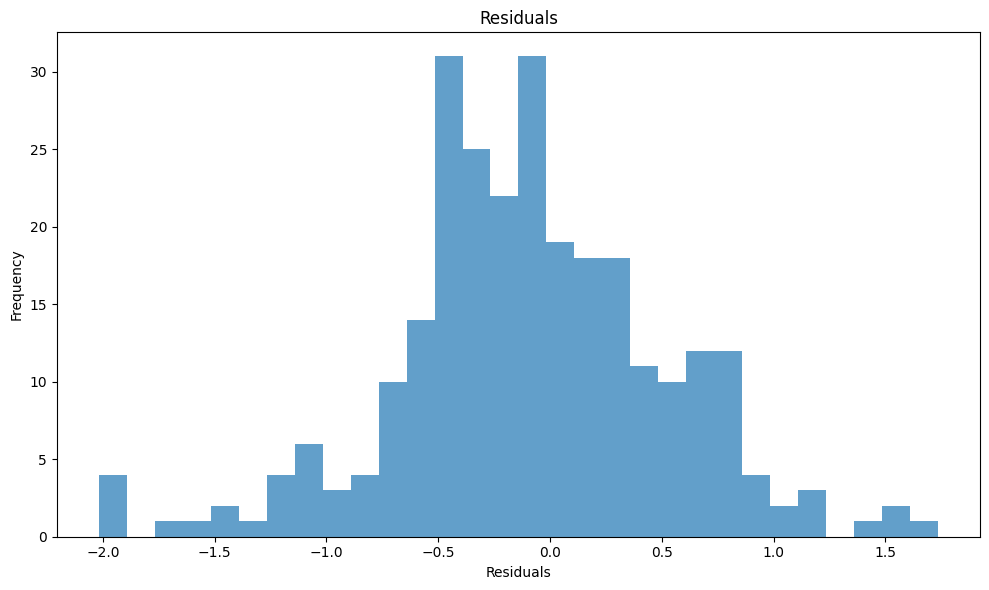

In [40]:
# Check how the prediction errors are distributed
residuals = y_test - y_test_pred

fig_residual_distribution, ax = plt.subplots(figsize=(10, 6))

ax.hist(residuals, bins=30, alpha=0.7)

ax.set_title("Residuals")
ax.set_xlabel("Residuals")
ax.set_ylabel("Frequency")

fig_residual_distribution.tight_layout()
plt.show()

### Observation

### 7.6 Residual vs Predicted

Residuals are plotted against predicted values to check whether the prediction errors show systematic patterns across the prediction range.

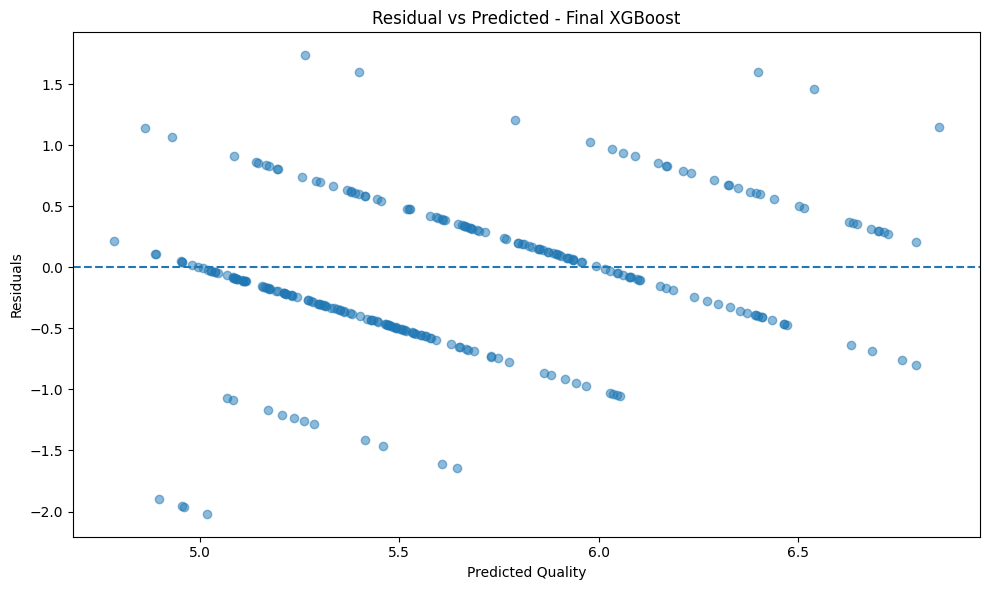

In [41]:
# Plot residuals against predicted values
fig_residual_predicted, ax = plt.subplots(figsize=(10, 6))

ax.scatter(y_test_pred, residuals, alpha=0.5)

# Add the zero-residual reference line
ax.axhline(y=0, linestyle="--")

ax.set_title("Residual vs Predicted - Final XGBoost")
ax.set_xlabel("Predicted Quality")
ax.set_ylabel("Residuals")
fig_residual_predicted.tight_layout()
plt.show()

### Observation

A fan/funnel shape here (residual spread widening or narrowing across
predicted values) would mean the model is more reliable in some quality
ranges than others — checked more directly in 7.7 below.

### 7.7 Rounded-Prediction Accuracy

R2, RMSE and MAE evaluate the model as a regression problem with continuous predictions. Since wine quality is recorded as a whole-number score, rounded predictions provide an additional view of exact-score and near-score predictions.

In [42]:
# Round prediction to the nearest valid quality score
y_test_pred_rounded = np.clip(
    np.round(y_test_pred),
    y_train.min(),
    y_train.max()
)

# Calculate exact-match accuracy
exact_match_accuracy = accuracy_score(
    y_test,
    y_test_pred_rounded
)

# Calculate predictions within one quality point
within_one_point = (
    np.abs(y_test.values - y_test_pred_rounded) <= 1
).mean()

print("=" * 70)
print("ROUNDED-PREDICTION ACCURACY")
print("-" * 70)
print(f"Exact-match accuracy: {exact_match_accuracy:.4f}")
print(f"Within one point: {within_one_point:.4f}")
print("=" * 70)

ROUNDED-PREDICTION ACCURACY
----------------------------------------------------------------------
Exact-match accuracy: 0.6360
Within one point: 0.9669


### Observation

The rounded predictions achieved an exact-match accuracy of 63.60%, while 96.69% of predictions were within one quality point of the actual score.

### 7.8 Feature Importance

Permutation importance is used to examine how much the model's R2 changes when each feature is randomly shuffled. A larger decrease indicates greater dependence of the model's predictive performance on that feature.

In [43]:
# Calculate permutation importance using R2
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42,
    n_jobs=N_JOBS
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
10,alcohol,0.286810
9,sulphates,0.157155
1,volatile acidity,0.094259
6,total sulfur dioxide,0.022345
8,pH,0.011608
7,density,0.011514
3,residual sugar,0.004219
4,chlorides,0.004105
0,fixed acidity,0.003965
5,free sulfur dioxide,0.003909


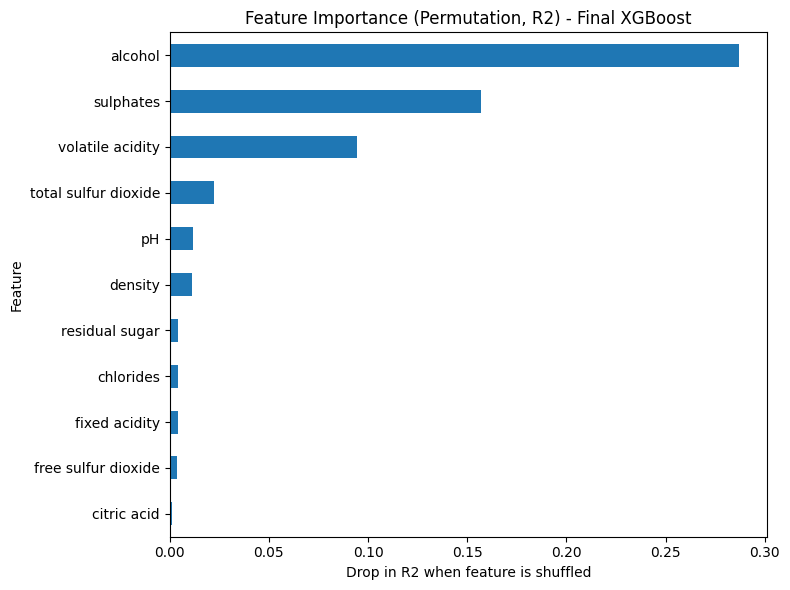

In [44]:
# Plot permutation feature importance
fig_feature_importance, ax = plt.subplots(figsize=(8, 6))

importance_df.sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    ax=ax
)

ax.set_title("Feature Importance (Permutation, R2) - Final XGBoost")
ax.set_xlabel("Drop in R2 when feature is shuffled")

fig_feature_importance.tight_layout()
plt.show()

### Observation

The permutation importance results show that alcohol, sulphates, and volatile acidity have the largest impact on the model's R2 when shuffled. The remaining features have substantially smaller importance values.

### 7.9 Error Analysis by Quality Score

Overall RMSE summarizes prediction error across the complete test set, but it does not show how error varies across individual quality scores. This analysis examines the mean absolute error for each actual quality level.

In [45]:
# Break down error by actual quality score
error_by_quality = pd.DataFrame({
    "Actual_Quality": y_test.values,
    "Predicted": y_test_pred,
    "Absolute_Error": np.abs(y_test.values - y_test_pred)
})

error_summary = error_by_quality.groupby("Actual_Quality").agg(
    Count=("Absolute_Error", "size"),
    Mean_Absolute_Error=("Absolute_Error", "mean")
)

error_summary

,Count,Mean_Absolute_Error
Actual_Quality,,
3,4,1.958303
4,11,1.312452
5,120,0.373317
6,103,0.358671
7,31,0.686738
8,3,1.402791


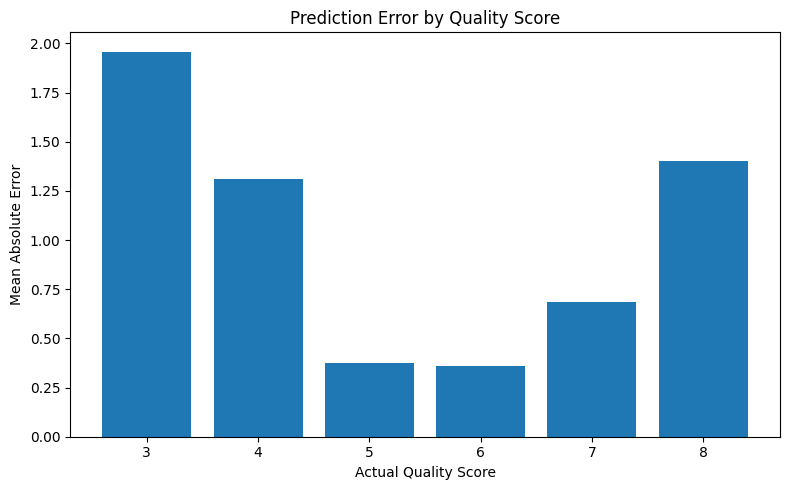

In [46]:
# plot mean absolute error by actual quality score
fig_error_by_quality, ax = plt.subplots(figsize=(8, 5))

plt.bar(
    error_summary.index.astype(str),
    error_summary["Mean_Absolute_Error"],
)

plt.title("Prediction Error by Quality Score")
plt.xlabel("Actual Quality Score")
plt.ylabel("Mean Absolute Error")

fig_error_by_quality.tight_layout()
plt.show()

### Observation

The model has the lowest mean absolute error for quality scores 5 and 6, which also contain the largest numbers of test samples. Error is higher for the less frequent quality scores, particularly scores 3, 4 and 8. The results for quality scores 3 and 8 should be interpreted cautiously because they contain only 4 and 3 test samples respectively.

## 8. MLflow Experiment Tracking

MLflow is used to track the final model, hyperparameters, evaluation metrics and supporting evaluation artifacts. This provides a reproducible record of the final experiment.

### 8.1 Final Model Logging

The final XGBoost model, Optuna parameters, evaluation metrics, and evaluation artifacts are logged to MLflow for experiment tracking and model deployment.

In [ ]:
# Close any active MLflow run before starting the final model run
if mlflow.active_run() is not None:
    mlflow.end_run()

# Infer the model input and output signature
signature = infer_signature(X_train, y_train_pred)

# Log the final model, its metrics and the evaluation charts to MLflow
with mlflow.start_run(run_name="best_model_experiment"):

    # Log model and experiment configuration
    mlflow.log_param("model", best_model_name)
    mlflow.log_param("optimization_method", "Optuna (TPE)")
    mlflow.log_param("cv_folds", CV)
    mlflow.log_param("scoring", "r2")
    mlflow.log_params(best_params)

    # Cross-validation result
    mlflow.log_metric("CV_R2", best_cv_r2)

    # Train metrics
    mlflow.log_metric("Train_R2", train_r2)
    mlflow.log_metric("Train_RMSE", train_rmse)
    mlflow.log_metric("Train_MAE", train_mae)

    # Test metrics
    mlflow.log_metric("Test_R2", test_r2)
    mlflow.log_metric("Test_RMSE", test_rmse)
    mlflow.log_metric("Test_MAE", test_mae)

    # Overfitting check
    mlflow.log_metric("R2_Gap", r2_gap)

    # Baseline comparison
    mlflow.log_metric("Baseline_R2", baseline_r2)
    mlflow.log_metric("Baseline_RMSE", baseline_rmse)
    mlflow.log_metric("Baseline_MAE", baseline_mae)

    # Supplementary evaluation
    mlflow.log_metric("Rounded_Exact_Match_Accuracy", exact_match_accuracy)
    mlflow.log_metric("Rounded_Within_One_Point", within_one_point)

    # Evaluation charts
    log_matplotlib_figure(fig_actual_predicted, "actual_vs_predicted")
    log_matplotlib_figure(fig_residual_distribution, "residual_distribution")
    log_matplotlib_figure(fig_residual_predicted, "residual_vs_predicted")
    log_matplotlib_figure(fig_feature_importance, "feature_importance")
    log_matplotlib_figure(fig_error_by_quality, "error_by_quality")

    # Supporting tables
    log_dataframe_artifact(importance_df, "feature_importance")
    log_dataframe_artifact(error_summary.reset_index(), "error_by_quality")

    # Final model artifact with signature and input example
    mlflow.xgboost.log_model(
        best_model,
        artifact_path="model",
        signature=signature,
        input_example=X_train.head()
    )

print("Final model, metrics and evaluation visuals logged to MLflow/DagsHub.")

/home/mdarif/miniconda3/envs/wine_ml/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [13:08:01] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


2026/09/28 13:08:28 INFO mlflow.tracking._tracking_service.client: 🏃 View run best_model_experiment at: https://dagshub.com/TechArif/wine-quality-prediction-system.mlflow/#/experiments/0/runs/b59ba33de5164aa79f4614b5e9051cef.
2026/09/28 13:08:28 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/TechArif/wine-quality-prediction-system.mlflow/#/experiments/0.


Final model, metrics and evaluation visuals logged to MLflow/DagsHub.


## 9. Conclusion

XGBoost ended up being the final model, and Optuna improved its cross-validation R² from 0.3554 to 0.3696. On the test set, the final model achieved an R² of 0.4568, RMSE of 0.6203, and MAE of 0.4761, with an R² gap of 0.0106.

The rounded predictions were within one quality point of the actual score for 96.69% of samples, while exact-match accuracy was 63.60%. Alcohol, sulphates, and volatile acidity were the most important features based on permutation importance.

Everything is logged to MLflow on DagsHub, including the final model, parameters, metrics, plots, and supporting evaluation artifacts.